# Kraken Spot-Perp Arbitrage — Backtester Framework

Loads parquet files produced by `kraken_arbitrage_test.ipynb` and runs the
divergence-convergence strategy through the `backtester` framework.

Set `TRADING_SYMBOL` to the Kraken spot altname (e.g., `XBTUSD`, `ETHUSD`) and
`FUTURES_SYMBOL` to the corresponding Kraken Futures perpetual (e.g., `PF_XBTUSD`).
Both parquet files must exist in `notebooks/kraken/data/`.

**Fee model**: Kraken taker/taker — spot 0.26 %, futures 0.05 %.

In [93]:
import json
import os
import sys
import time
from pathlib import Path

import pandas as pd
import requests

# Ensure backtester is importable when running from the project root
_src = Path(os.getcwd()) / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, PositionSide
from backtester.market import Market, MarketDataFromCSV
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import AllocationPosition, CloseReason, Strategy

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

cwd          = Path(os.getcwd())
notebook_dir = cwd / "notebooks" / "kraken"
data_dir     = notebook_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)
print(f"CWD      : {cwd}")
print(f"Data dir : {data_dir}")

CWD      : /Users/nick/Documents/www/alphakit/backtesting
Data dir : /Users/nick/Documents/www/alphakit/backtesting/notebooks/kraken/data


In [94]:
# ── Configuration ─────────────────────────────────────────────────────────────
TRADING_SYMBOL   = "FETUSD"    # Kraken spot altname
FUTURES_SYMBOL   = "PF_FETUSD" # Kraken Futures PF_ perpetual

INTERVAL         = 1
UNIT_OF_TIME     = "minute"
DATE_FROM        = "2026-04-10 00:00:00"   # 2 months of history
DATE_TO          = "2026-06-10 00:00:00"
TRAIN_WINDOW_DAYS         = 7              # first 7 days → calibration, ~53 days → backtest
# FET: abs(spread) p90 ≈ 37 bps — clears the 36 bps maker fee hurdle
# 10.3% of train minutes exceed 36 bps, spreads up to ±325 bps
ENTRY_THRESHOLD_QUANTILE  = 0.90
EXIT_THRESHOLD_QUANTILE   = 0.35
STARTING_BALANCE_QUOTE    = 1_000.0

# Kraken fees
KRAKEN_SPOT_TAKER_FEE    = 0.0026
KRAKEN_SPOT_MAKER_FEE    = 0.0016
KRAKEN_FUTURES_TAKER_FEE = 0.0005
KRAKEN_FUTURES_MAKER_FEE = 0.0002

# Backtester symbols (internal format)
QUOTE      = "USD"
BASE_ASSET = TRADING_SYMBOL.replace(QUOTE, "")
SPOT_SYMBOL = f"{BASE_ASSET}_SPOT/{QUOTE}"
PERP_SYMBOL = f"{BASE_ASSET}_PERP/{QUOTE}"


def format_cache_timestamp(ts_text: str) -> str:
    return pd.Timestamp(ts_text, tz="UTC").strftime("%Y-%m-%dT%H-%M-%S+00-00")


CACHE_DATE_FROM = format_cache_timestamp(DATE_FROM)
CACHE_DATE_TO   = format_cache_timestamp(DATE_TO)

spot_parquet = data_dir / f"{TRADING_SYMBOL}__spot__1m__{CACHE_DATE_FROM}__{CACHE_DATE_TO}.parquet"
perp_parquet = data_dir / f"{FUTURES_SYMBOL}__usd_perpetual__1m__{CACHE_DATE_FROM}__{CACHE_DATE_TO}.parquet"
spot_csv     = data_dir / f"{TRADING_SYMBOL}_spot_1m.csv"
perp_csv     = data_dir / f"{FUTURES_SYMBOL}_perp_1m.csv"

print(f"Symbol         : {TRADING_SYMBOL} (spot) / {FUTURES_SYMBOL} (perp)")
print(f"Window         : {DATE_FROM[:10]} → {DATE_TO[:10]}  (train {TRAIN_WINDOW_DAYS}d + test ~{60 - TRAIN_WINDOW_DAYS}d)")
print(f"Spot parquet   : {spot_parquet.name}  {'✓' if spot_parquet.exists() else '↓ will download'}")
print(f"Futures parquet: {perp_parquet.name}  {'✓' if perp_parquet.exists() else '↓ will download'}")

Symbol         : FETUSD (spot) / PF_FETUSD (perp)
Window         : 2026-04-10 → 2026-06-10  (train 7d + test ~53d)
Spot parquet   : FETUSD__spot__1m__2026-04-10T00-00-00+00-00__2026-06-10T00-00-00+00-00.parquet  ✓
Futures parquet: PF_FETUSD__usd_perpetual__1m__2026-04-10T00-00-00+00-00__2026-06-10T00-00-00+00-00.parquet  ✓


In [95]:
# ── Download helpers ──────────────────────────────────────────────────────────
# Spot: reconstruct 1m OHLC from /Trades (Kraken retains only ~12 h of 1m OHLC bars
#       but has full tick history via /Trades).
# Futures: paginate Kraken Charts API (more_candles cursor).
# Both: parquet-cached; re-running the cell is a no-op if files already exist.

_http = requests.Session()
_http.headers.update({"User-Agent": "alphakit-kraken-arb/0.1"})

_SPOT_BASE    = "https://api.kraken.com/0/public"
_INTERVAL_STR = "1m"
_INTERVAL_MIN = 1


def _kraken_get(base, path, params=None, retries=5):
    for attempt in range(retries):
        try:
            r = _http.get(f"{base}{path}", params=params, timeout=30)
            if r.status_code == 429:
                time.sleep(2 * (attempt + 1))
                continue
            r.raise_for_status()
            return r.json()
        except requests.RequestException:
            time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Request failed after {retries} attempts: {base}{path}")


def _to_unix_s(iso_str):
    return int(pd.Timestamp(iso_str).timestamp())


def _download_spot(altname, start_iso, end_iso):
    """Paginate /Trades and resample to 1m OHLC."""
    end_s    = _to_unix_s(end_iso)
    since_ns = str(_to_unix_s(start_iso) * 1_000_000_000)
    prices, volumes, times = [], [], []
    page = 0
    while True:
        data = _kraken_get(_SPOT_BASE, "/Trades",
                           {"pair": altname, "since": since_ns, "count": 1000})
        if data.get("error"):
            raise ValueError(f"/Trades error for {altname}: {data['error']}")
        result  = data["result"]
        next_ns = str(result["last"])
        key     = next(k for k in result if k != "last")
        trades  = result[key]
        if not trades:
            break
        done = False
        for t in trades:
            ts = float(t[2])
            if ts >= end_s:
                done = True
                break
            prices.append(float(t[0]))
            volumes.append(float(t[1]))
            times.append(ts)
        if done or next_ns == since_ns:
            break
        since_ns = next_ns
        page += 1
        if page % 50 == 0:
            print(f"    {altname} spot: {page} pages, {len(prices):,} ticks so far …")
        time.sleep(1.2)

    if not prices:
        return pd.DataFrame()

    idx  = pd.DatetimeIndex(pd.to_datetime(times, unit="s", utc=True), name="timestamp")
    ohlc = pd.Series(prices, index=idx).resample("1min", label="left", closed="left").ohlc()
    vol  = pd.Series(volumes, index=idx, name="volume").resample("1min", label="left", closed="left").sum()
    df   = ohlc.join(vol).dropna(subset=["close"]).reset_index()
    df   = df[(df["timestamp"] >= pd.Timestamp(start_iso, tz="UTC")) &
              (df["timestamp"] <  pd.Timestamp(end_iso,   tz="UTC"))]
    df["symbol"] = altname; df["market_type"] = "spot"; df["interval"] = _INTERVAL_STR
    return df.drop_duplicates("timestamp").sort_values("timestamp").reset_index(drop=True)


def _download_futures(symbol, start_iso, end_iso):
    """Paginate Kraken Charts API with more_candles cursor."""
    from_s = _to_unix_s(start_iso); to_s = _to_unix_s(end_iso); cursor = from_s
    rows = []
    while cursor < to_s:
        r = _http.get(
            f"https://futures.kraken.com/api/charts/v1/trade/{symbol}/{_INTERVAL_STR}",
            params={"from": cursor, "to": to_s}, timeout=30)
        r.raise_for_status()
        payload = r.json()
        candles = payload.get("candles", [])
        if not candles:
            break
        for c in candles:
            if int(c["time"]) // 1000 >= to_s:
                break
            rows.append({
                "timestamp": pd.Timestamp(int(c["time"]), unit="ms", tz="UTC"),
                "open": float(c["open"]), "high": float(c["high"]),
                "low":  float(c["low"]),  "close": float(c["close"]),
                "volume": float(c.get("volume", 0)),
            })
        if not payload.get("more_candles", False):
            break
        cursor = int(candles[-1]["time"]) // 1000 + _INTERVAL_MIN * 60
        time.sleep(0.2)

    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df = df[df["timestamp"] < pd.Timestamp(end_iso, tz="UTC")]
    df["symbol"] = symbol; df["market_type"] = "usd_perpetual"; df["interval"] = _INTERVAL_STR
    return df.drop_duplicates("timestamp").sort_values("timestamp").reset_index(drop=True)


def _ensure_parquet(symbol, market_type, parquet_path, start_iso, end_iso):
    if parquet_path.exists():
        n = len(pd.read_parquet(parquet_path))
        print(f"  [cached]  {parquet_path.name}  ({n:,} rows)")
        return
    print(f"  [download] {symbol} ({market_type})  {start_iso[:10]} → {end_iso[:10]}")
    df = (_download_spot(symbol, start_iso, end_iso) if market_type == "spot"
          else _download_futures(symbol, start_iso, end_iso))
    if df.empty:
        raise ValueError(f"No data returned for {symbol} {market_type}")
    df.to_parquet(parquet_path, index=False)
    print(f"           → {len(df):,} rows saved")


print(f"Fetching data for {TRADING_SYMBOL} / {FUTURES_SYMBOL} …")
_ensure_parquet(TRADING_SYMBOL, "spot",          spot_parquet, DATE_FROM, DATE_TO)
_ensure_parquet(FUTURES_SYMBOL, "usd_perpetual", perp_parquet, DATE_FROM, DATE_TO)
print("Done.")

Fetching data for FETUSD / PF_FETUSD …
  [cached]  FETUSD__spot__1m__2026-04-10T00-00-00+00-00__2026-06-10T00-00-00+00-00.parquet  (44,754 rows)
  [cached]  PF_FETUSD__usd_perpetual__1m__2026-04-10T00-00-00+00-00__2026-06-10T00-00-00+00-00.parquet  (87,840 rows)
Done.


In [96]:
# ── Load parquet files, export to CSV, build indicator frame ──────────────────

def parquet_to_csv(parquet_path: Path, csv_path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(parquet_path).copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True)
    frame = frame.sort_values("timestamp").reset_index(drop=True)
    frame.to_csv(csv_path, index=False)
    return frame


spot_raw = parquet_to_csv(spot_parquet, spot_csv)
perp_raw = parquet_to_csv(perp_parquet, perp_csv)

merged_raw = (
    spot_raw.merge(perp_raw, on="timestamp", suffixes=("_spot", "_perp"), how="inner")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

for col in ["open", "high", "low", "close"]:
    merged_raw[f"divergence_{col}_bps"] = (
        (merged_raw[f"{col}_perp"] - merged_raw[f"{col}_spot"])
        / merged_raw[f"{col}_spot"] * 10_000
    )

indicator_frame = pd.DataFrame({
    "timestamp":     merged_raw["timestamp"],
    "divergence_bps": merged_raw["divergence_close_bps"],
    "spot_close":    merged_raw["close_spot"],
    "perp_close":    merged_raw["close_perp"],
    "spot_open":     merged_raw["open_spot"],
    "perp_open":     merged_raw["open_perp"],
})

dataset_start         = indicator_frame["timestamp"].min()
train_end_exclusive   = dataset_start + pd.Timedelta(days=TRAIN_WINDOW_DAYS)
train_frame           = indicator_frame[indicator_frame["timestamp"] < train_end_exclusive].copy()
test_frame            = indicator_frame[indicator_frame["timestamp"] >= train_end_exclusive].copy()

if train_frame.empty or test_frame.empty:
    raise ValueError(
        "Dataset does not span both a training window and a test window. "
        "Adjust DATE_FROM / DATE_TO or TRAIN_WINDOW_DAYS."
    )

train_abs = train_frame["divergence_bps"].abs()
ENTRY_DIVERGENCE_BPS = float(train_abs.quantile(ENTRY_THRESHOLD_QUANTILE))
EXIT_DIVERGENCE_BPS  = float(train_abs.quantile(EXIT_THRESHOLD_QUANTILE))
EXIT_DIVERGENCE_BPS  = min(EXIT_DIVERGENCE_BPS, ENTRY_DIVERGENCE_BPS * 0.5)
EXIT_DIVERGENCE_BPS  = max(EXIT_DIVERGENCE_BPS, ENTRY_DIVERGENCE_BPS * 0.1)

TEST_DATE_FROM = test_frame["timestamp"].min().strftime("%Y-%m-%d %H:%M:%S")
TEST_DATE_TO   = test_frame["timestamp"].max().strftime("%Y-%m-%d %H:%M:%S")

print(f"Trading symbol   : {TRADING_SYMBOL} spot / {FUTURES_SYMBOL} perp")
print(f"Train rows       : {len(train_frame):,}")
print(f"Test rows        : {len(test_frame):,}")
print(f"Entry divergence : {ENTRY_DIVERGENCE_BPS:.4f} bps")
print(f"Exit divergence  : {EXIT_DIVERGENCE_BPS:.4f} bps")
print(f"Test window      : {TEST_DATE_FROM} → {TEST_DATE_TO}")
display(train_frame[["timestamp", "divergence_bps"]].head())
display(test_frame[["timestamp", "divergence_bps"]].head())

Trading symbol   : FETUSD spot / PF_FETUSD perp
Train rows       : 4,800
Test rows        : 39,954
Entry divergence : 44.0341 bps
Exit divergence  : 10.6578 bps
Test window      : 2026-04-17 00:00:00 → 2026-06-09 23:54:00


,timestamp,divergence_bps
0,2026-04-10 00:00:00+00:00,8.997955
1,2026-04-10 00:01:00+00:00,16.353230
2,2026-04-10 00:05:00+00:00,8.146640
3,2026-04-10 00:08:00+00:00,2.861815
4,2026-04-10 00:09:00+00:00,6.952965


,timestamp,divergence_bps
4800,2026-04-17 00:00:00+00:00,8.753647
4801,2026-04-17 00:01:00+00:00,17.104714
4802,2026-04-17 00:02:00+00:00,28.750000
4803,2026-04-17 00:04:00+00:00,16.229713
4804,2026-04-17 00:05:00+00:00,16.229713


In [97]:
# ── Build Market object ────────────────────────────────────────────────────────

market = Market()

spot_market = MarketDataFromCSV(
    symbol=SPOT_SYMBOL,
    date_from=TEST_DATE_FROM,
    date_to=TEST_DATE_TO,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    path=str(spot_csv),
).get_df()

perp_market = MarketDataFromCSV(
    symbol=PERP_SYMBOL,
    date_from=TEST_DATE_FROM,
    date_to=TEST_DATE_TO,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    path=str(perp_csv),
).get_df()

market.add_market(symbol=SPOT_SYMBOL, df=spot_market)
market.add_market(symbol=PERP_SYMBOL, df=perp_market)

indicator_market = test_frame.copy()
indicator_market["time_open"]  = pd.to_datetime(indicator_market["timestamp"], utc=True).dt.tz_localize(None)
indicator_market["time_close"] = indicator_market["time_open"] + pd.Timedelta(minutes=INTERVAL) - pd.Timedelta(milliseconds=1)
indicator_market = indicator_market.set_index("time_close")
indicator_market = indicator_market.reindex(spot_market.index)

for sym in [SPOT_SYMBOL, PERP_SYMBOL]:
    market.add_indicator(
        symbol=sym,
        interval=INTERVAL,
        unit_of_time=UNIT_OF_TIME,
        indicator_name="divergence_bps",
        df=indicator_market["divergence_bps"],
    )

market.compile()

print(f"Test window  : {TEST_DATE_FROM} → {TEST_DATE_TO}")
print(f"Spot rows    : {len(spot_market):,}")
print(f"Perp rows    : {len(perp_market):,}")
print(f"Compiled bars: {len(market.index_num_ts):,}")
display(indicator_market[["divergence_bps", "spot_close", "perp_close"]].head())

/Users/nick/Documents/www/alphakit/backtesting/src/backtester/market.py:35: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["time"] = df["time"].view("int64") // 10**9
/Users/nick/Documents/www/alphakit/backtesting/src/backtester/market.py:38: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df["time_close"] = df["time_open"] + pd.Timedelta(timedelta) - pd.Timedelta("1ms")
/Users/nick/Documents/www/alphakit/backtesting/src/backtester/market.py:42: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample(timedelta).agg(
/Users/nick/Documents/www/alphakit/backtesting/src/backtester/market.py:55: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df["time_close"] = df["time_open"] + pd.Timedelta(timedelta) - pd.Timedelta

Test window  : 2026-04-17 00:00:00 → 2026-06-09 23:54:00
Spot rows    : 77,754
Perp rows    : 77,754
Compiled bars: 77,754


,divergence_bps,spot_close,perp_close
ts,,,
2026-04-17 00:00:59.999,8.753647,0.2399,0.24011
2026-04-17 00:01:59.999,17.104714,0.2397,0.24011
2026-04-17 00:02:59.999,28.750000,0.2400,0.24069
2026-04-17 00:03:59.999,NaN,NaN,NaN
2026-04-17 00:04:59.999,16.229713,0.2403,0.24069


In [98]:
# ── Strategy definition ────────────────────────────────────────────────────────

class DivergenceLegStrategy(Strategy):
    def __init__(
        self,
        key: str,
        market: Market,
        symbol: str,
        side: PositionSide,
        divergence_indicator_key: str,
        entry_divergence_bps: float,
        exit_divergence_bps: float,
        position_percent: float,
    ):
        super().__init__(key, market, symbol)
        self.side                     = side
        self.divergence_indicator_key = divergence_indicator_key
        self.entry_divergence_bps     = entry_divergence_bps
        self.exit_divergence_bps      = exit_divergence_bps
        self.position_percent         = position_percent

    def has_open_position(self) -> bool:
        return any(p.symbol == self.symbol for p in self.allocation.positions)

    def should_enter(self, divergence: float) -> bool:
        return divergence >= self.entry_divergence_bps

    def should_exit(self, divergence: float) -> bool:
        return abs(divergence) <= self.exit_divergence_bps

    def refresh(self):
        divergence = self.market.current[self.symbol]["indicators"].get(self.divergence_indicator_key)
        if pd.isna(divergence):
            return
        divergence    = float(divergence)
        price         = float(self.market.current[self.symbol]["close"])
        current_num   = self.market.current["num"]
        is_last       = current_num == len(self.market.index_num_ts) - 1
        has_position  = self.has_open_position()

        if (not has_position) and self.should_enter(divergence):
            self.allocation.positions = [
                AllocationPosition(
                    side=self.side,
                    symbol=self.symbol,
                    percent=self.position_percent,
                    average_open_price=price,
                )
            ]
            self.allocation.orders = []
            self._mark_allocation_changed()
            self.open_trade(side=self.side, open_price=price)
            return

        if has_position and (self.should_exit(divergence) or is_last):
            self.allocation.positions = []
            self.allocation.orders    = []
            self._mark_allocation_changed()
            self.close_trade(
                close_price=price,
                reason=CloseReason.convergence if self.should_exit(divergence) else CloseReason.end_of_test,
            )


LEG_ALLOCATION = 0.5

exchange = Exchange(
    market=market,
    slippage=0.0005,
    maker_fee=KRAKEN_FUTURES_MAKER_FEE,
    taker_fee=KRAKEN_FUTURES_TAKER_FEE,
    market_type=MarketType.future,
    max_leverage=2,
    margin_allocation_type=MarginAllocationType.cross,
)

portfolio = Portfolio(
    weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=DivergenceLegStrategy(
                key=f"{BASE_ASSET}_spot_long",
                market=market,
                symbol=SPOT_SYMBOL,
                side=PositionSide.long,
                divergence_indicator_key="divergence_bps",
                entry_divergence_bps=ENTRY_DIVERGENCE_BPS,
                exit_divergence_bps=EXIT_DIVERGENCE_BPS,
                position_percent=LEG_ALLOCATION,
            ),
        ),
        WeightedStrategy(
            weight=1.0,
            strategy=DivergenceLegStrategy(
                key=f"{BASE_ASSET}_perp_short",
                market=market,
                symbol=PERP_SYMBOL,
                side=PositionSide.short,
                divergence_indicator_key="divergence_bps",
                entry_divergence_bps=ENTRY_DIVERGENCE_BPS,
                exit_divergence_bps=EXIT_DIVERGENCE_BPS,
                position_percent=LEG_ALLOCATION,
            ),
        ),
    ],
    output_scale=1,
)

reporter = PerformanceAnalyzer(
    market=market,
    exchange=exchange,
    portfolio=portfolio,
    benchmark_symbols=[SPOT_SYMBOL, PERP_SYMBOL],
)

print(f"Portfolio ready: {TRADING_SYMBOL} — 50% long spot / 50% short perp")
print(f"Exchange fee model: futures taker {KRAKEN_FUTURES_TAKER_FEE:.4%} / maker {KRAKEN_FUTURES_MAKER_FEE:.4%}")
print(f"Entry divergence: {ENTRY_DIVERGENCE_BPS:.4f} bps")
print(f"Exit divergence : {EXIT_DIVERGENCE_BPS:.4f} bps")

Portfolio ready: FETUSD — 50% long spot / 50% short perp
Exchange fee model: futures taker 0.0500% / maker 0.0200%
Entry divergence: 44.0341 bps
Exit divergence : 10.6578 bps


In [99]:
# ── Run backtest ──────────────────────────────────────────────────────────────

market.reset()
backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter)
backtest.exchange.transactions.add_deposit(asset=QUOTE, volume=STARTING_BALANCE_QUOTE)
backtest.run_all()

report_df = backtest.reporter.merged.copy() if backtest.reporter.merged is not None else pd.DataFrame()
trade_df  = pd.DataFrame([t.__dict__ for t in backtest.reporter.trades])

if not trade_df.empty:
    trade_df["holding_minutes"] = (
        pd.to_datetime(trade_df["time_close"]) - pd.to_datetime(trade_df["time_open"])
    ).dt.total_seconds() / 60
else:
    trade_df = pd.DataFrame(columns=[
        "symbol", "side", "time_open", "time_close",
        "open_price", "close_price", "close_reason",
        "profit", "loss", "pnl", "result", "holding_minutes",
    ])

pair_trade_summary = {
    "trading_symbol":       TRADING_SYMBOL,
    "futures_symbol":       FUTURES_SYMBOL,
    "closed_trades":        int(len(trade_df)),
    "winner_trades":        int((trade_df["pnl"] > 0).sum()) if not trade_df.empty else 0,
    "loser_trades":         int((trade_df["pnl"] <= 0).sum()) if not trade_df.empty else 0,
    "avg_trade_pnl_ratio":  float(trade_df["pnl"].mean()) if not trade_df.empty else 0.0,
    "avg_holding_minutes":  float(trade_df["holding_minutes"].mean()) if not trade_df.empty else 0.0,
}

print(f"Candles processed: {backtest.market.current['num']}")
print(
    f"Note: two-leg portfolio — 50% long spot / 50% short perp for {TRADING_SYMBOL}. "
    "The framework exchange model is a proxy; use reporter.summary for indicative metrics only."
)
print("Pair trade summary:", json.dumps(pair_trade_summary, indent=2, default=str))
print(f"Executed trades: {len(trade_df):,}")

if not trade_df.empty:
    display(
        trade_df[[
            "symbol", "side", "time_open", "time_close",
            "open_price", "close_price", "pnl",
            "holding_minutes", "close_reason", "result",
        ]].head(20)
    )

if not report_df.empty:
    print("Reporter summary:", json.dumps(backtest.reporter.summary, indent=2, default=str))
    display(report_df.tail())

Candles processed: 77753
Note: two-leg portfolio — 50% long spot / 50% short perp for FETUSD. The framework exchange model is a proxy; use reporter.summary for indicative metrics only.
Pair trade summary: {
  "trading_symbol": "FETUSD",
  "futures_symbol": "PF_FETUSD",
  "closed_trades": 1434,
  "winner_trades": 974,
  "loser_trades": 460,
  "avg_trade_pnl_ratio": 0.00272596442240768,
  "avg_holding_minutes": 8.467224546722454
}
Executed trades: 1,434


,symbol,side,time_open,time_close,open_price,close_price,pnl,holding_minutes,close_reason,result
0,FET_SPOT/USD,PositionSide.long,2026-04-17 00:08:59.999,2026-04-17 01:01:59.999,0.2392,0.2390,-0.000836,53.0,CloseReason.convergence,TradeResult.loser
1,FET_SPOT/USD,PositionSide.long,2026-04-17 01:50:59.999,2026-04-17 01:54:59.999,0.2348,0.2347,-0.000426,4.0,CloseReason.convergence,TradeResult.loser
2,FET_SPOT/USD,PositionSide.long,2026-04-17 02:08:59.999,2026-04-17 03:49:59.999,0.2359,0.2325,-0.014413,101.0,CloseReason.convergence,TradeResult.loser
3,FET_SPOT/USD,PositionSide.long,2026-04-17 06:56:59.999,2026-04-17 07:05:59.999,0.2315,0.2319,0.001728,9.0,CloseReason.convergence,TradeResult.winner
4,FET_SPOT/USD,PositionSide.long,2026-04-17 07:18:59.999,2026-04-17 07:30:59.999,0.2307,0.2317,0.004335,12.0,CloseReason.convergence,TradeResult.winner
5,FET_SPOT/USD,PositionSide.long,2026-04-17 08:15:59.999,2026-04-17 08:34:59.999,0.2314,0.2322,0.003457,19.0,CloseReason.convergence,TradeResult.winner
6,FET_SPOT/USD,PositionSide.long,2026-04-17 08:41:59.999,2026-04-17 08:48:59.999,0.2313,0.2327,0.006053,7.0,CloseReason.convergence,TradeResult.winner
7,FET_SPOT/USD,PositionSide.long,2026-04-17 08:58:59.999,2026-04-17 09:26:59.999,0.2317,0.2322,0.002158,28.0,CloseReason.convergence,TradeResult.winner
8,FET_SPOT/USD,PositionSide.long,2026-04-17 10:09:59.999,2026-04-17 11:02:59.999,0.2318,0.2305,-0.005608,53.0,CloseReason.convergence,TradeResult.loser
9,FET_SPOT/USD,PositionSide.long,2026-04-17 13:46:59.999,2026-04-17 13:49:59.999,0.2374,0.2385,0.004634,3.0,CloseReason.convergence,TradeResult.winner


Reporter summary: {
  "algo": {
    "sharpe_ratio": 18.270524066961702,
    "sortino_ratio": 0.0,
    "annualized_volatility_percent": 18.857170483380557,
    "cagr_percent": 2933.2769281381657,
    "calmar_ratio": 0.0,
    "recovery_factor": 0.0,
    "max_drawdown_percent": -0.0,
    "gross_return_percent": 164.12765006627848,
    "net_return_percent": 64.12765006627848,
    "profit_factor": 4.017765139187356,
    "win_rate_percent": 67.92189679218968,
    "avg_win_loss_ratio": 1.8975071499242133,
    "max_consecutive_losses": 8.0,
    "avg_holding_period_min": 8.467224546722456,
    "closed_trades": 1434.0,
    "winner_trades": 974.0,
    "loser_trades": 460.0
  },
  "FET_SPOT/USD": {
    "sharpe_ratio": -0.4984278450131379,
    "sortino_ratio": -0.7026910630206545,
    "annualized_volatility_percent": 98.21848517515073,
    "cagr_percent": -61.98327834550783,
    "calmar_ratio": -2.1159285594323283,
    "recovery_factor": -0.4472624835053382,
    "max_drawdown_percent": -29.2937,
  

,time_open,time_close,algo__simple_returns,algo__log_returns,algo__cumulative_returns,algo__drawdown,algo__exchange_long_exposure,algo__exchange_short_exposure,algo__exchange_net_exposure,algo__exchange_gross_exposure,algo__portfolio_long_exposure,algo__portfolio_short_exposure,algo__portfolio_net_exposure,algo__portfolio_gross_exposure,FET_SPOT/USD__simple_returns,FET_SPOT/USD__log_returns,FET_SPOT/USD__cumulative_returns,FET_SPOT/USD__drawdown,FET_PERP/USD__simple_returns,FET_PERP/USD__log_returns,FET_PERP/USD__cumulative_returns,FET_PERP/USD__drawdown
ts,,,,,,,,,,,,,,,,,,,,,,
2026-06-05,2026-06-05,2026-06-05 23:59:59.999,0.050347,0.049121,1.539060,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.087460,-0.091523,0.855531,-0.292937,-0.085359,-0.089224,0.856547,-0.292776
2026-06-06,2026-06-06,2026-06-06 23:59:59.999,0.025544,0.025224,1.578374,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015720,0.015598,0.868980,-0.281821,0.016129,0.016000,0.870362,-0.281369
2026-06-07,2026-06-07,2026-06-07 23:59:59.999,0.021362,0.021137,1.612091,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.062406,0.060537,0.923210,-0.237003,0.061146,0.059350,0.923582,-0.237427
2026-06-08,2026-06-08,2026-06-08 23:59:59.999,0.007642,0.007613,1.624411,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.015977,-0.016106,0.908460,-0.249193,-0.014394,-0.014499,0.910288,-0.248404
2026-06-09,2026-06-09,2026-06-09 23:53:59.999,0.010382,0.010329,1.641277,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.043457,-0.044430,0.868980,-0.281821,-0.045196,-0.046250,0.869146,-0.282373


,time,message
1415,2026-06-09 14:04:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1416,2026-06-09 14:15:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1417,2026-06-09 15:23:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1418,2026-06-09 15:31:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1419,2026-06-09 16:15:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1420,2026-06-09 16:20:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1421,2026-06-09 17:38:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1422,2026-06-09 17:41:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1423,2026-06-09 17:47:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1424,2026-06-09 17:55:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...


,divergence_bps,spot_close,perp_close,entry_signal,exit_signal
ts,,,,,
2026-04-17 00:00:59.999,8.753647,0.2399,0.24011,False,True
2026-04-17 00:01:59.999,17.104714,0.2397,0.24011,False,False
2026-04-17 00:02:59.999,28.750000,0.2400,0.24069,False,False
2026-04-17 00:03:59.999,NaN,NaN,NaN,False,False
2026-04-17 00:04:59.999,16.229713,0.2403,0.24069,False,False
2026-04-17 00:05:59.999,16.229713,0.2403,0.24069,False,False
2026-04-17 00:06:59.999,NaN,NaN,NaN,False,False
2026-04-17 00:07:59.999,NaN,NaN,NaN,False,False
2026-04-17 00:08:59.999,62.290970,0.2392,0.24069,True,False


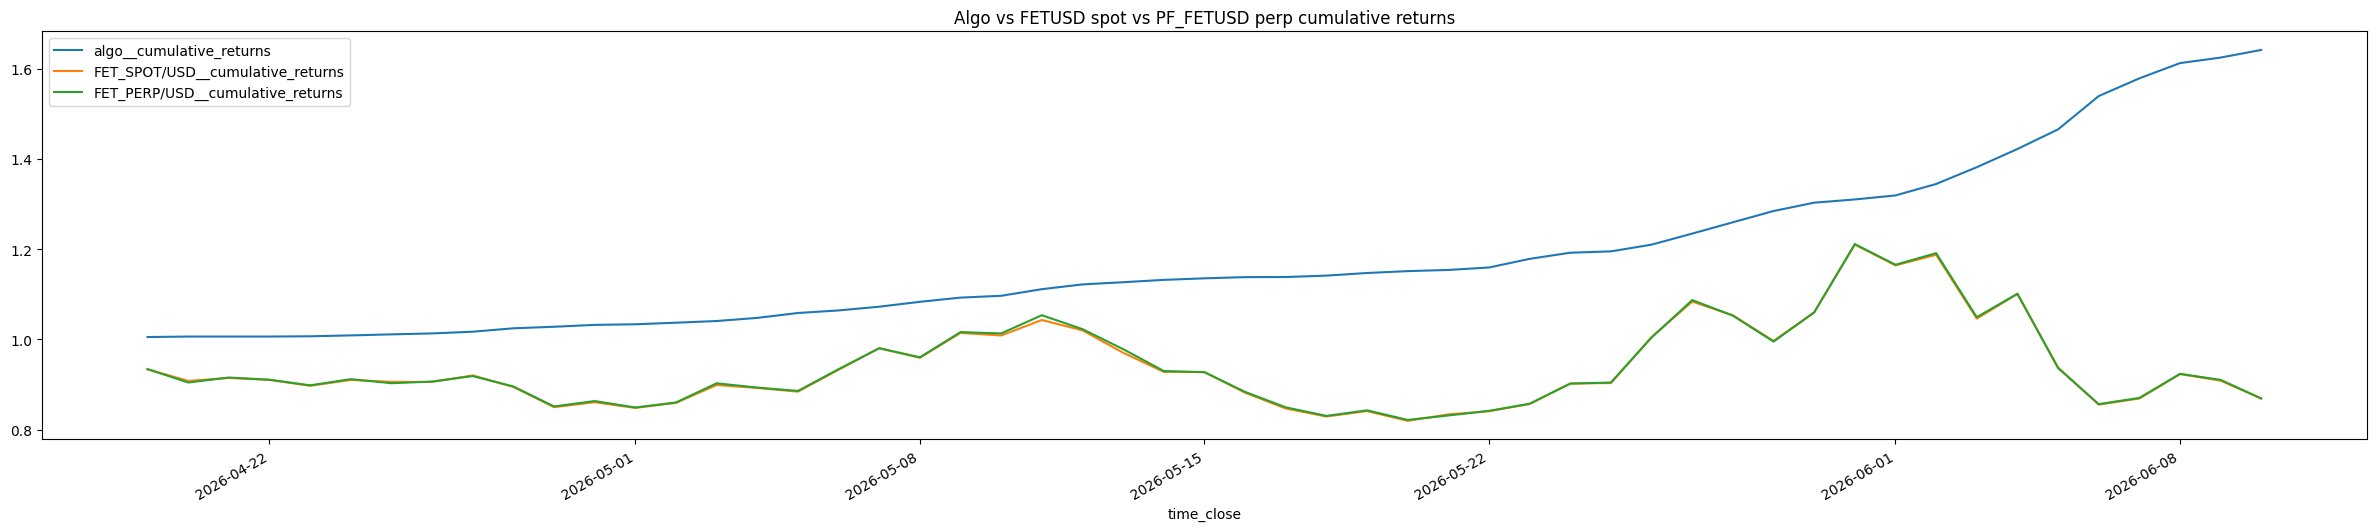

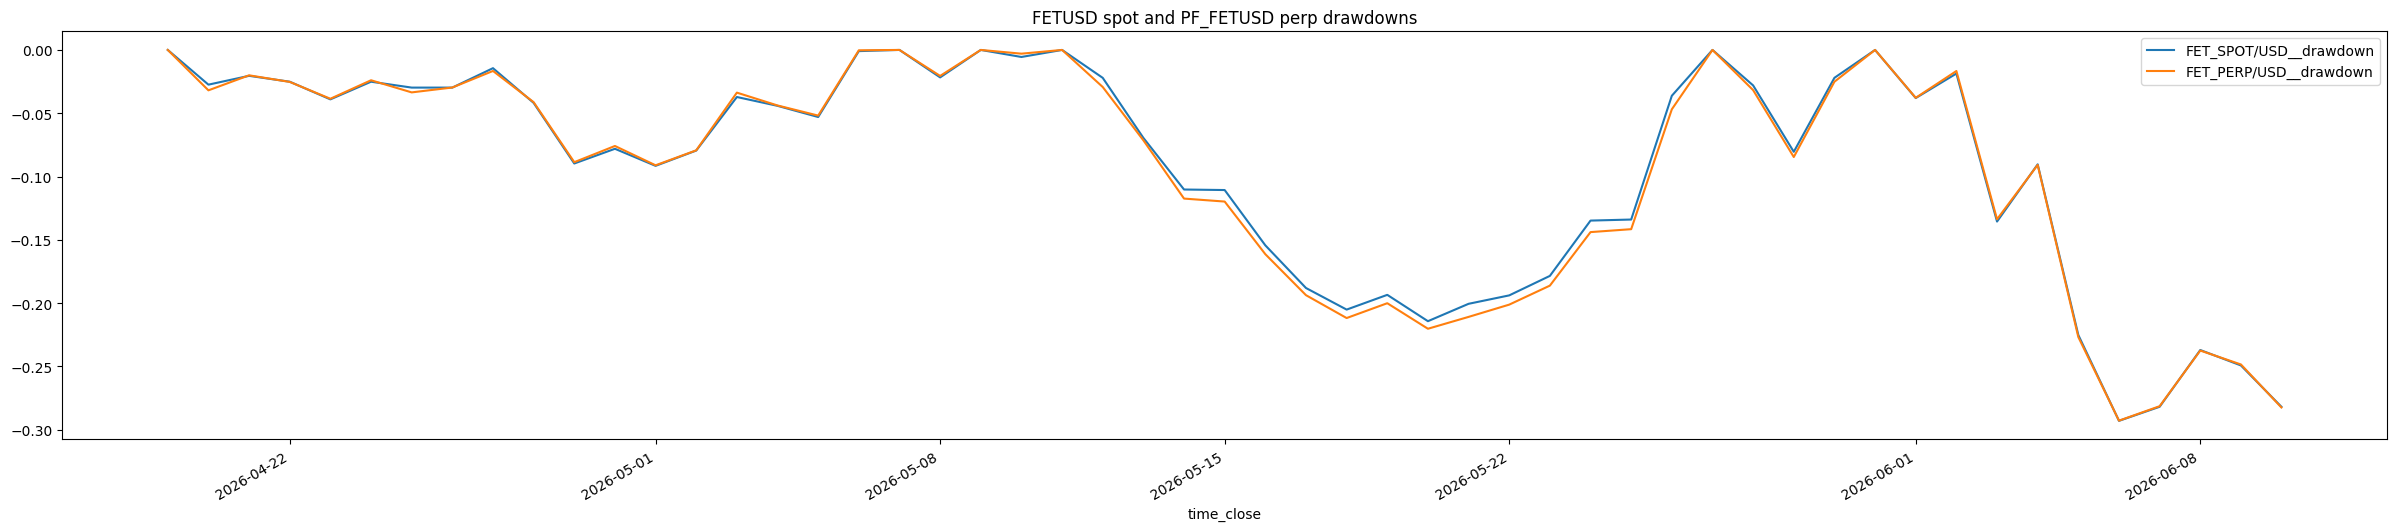

In [100]:
# ── Equity curve and spread charts ────────────────────────────────────────────

if not report_df.empty:
    report_df.plot(
        x="time_close",
        y=[
            "algo__cumulative_returns",
            f"{SPOT_SYMBOL}__cumulative_returns",
            f"{PERP_SYMBOL}__cumulative_returns",
        ],
        figsize=(30, 6),
        title=f"Algo vs {TRADING_SYMBOL} spot vs {FUTURES_SYMBOL} perp cumulative returns",
    )
    report_df.plot(
        x="time_close",
        y=[f"{SPOT_SYMBOL}__drawdown", f"{PERP_SYMBOL}__drawdown"],
        figsize=(30, 6),
        title=f"{TRADING_SYMBOL} spot and {FUTURES_SYMBOL} perp drawdowns",
    )

exchange_logs = pd.DataFrame(backtest.exchange.get_logs())
if not exchange_logs.empty:
    display(exchange_logs.tail(20))

spread_view = indicator_market[["divergence_bps", "spot_close", "perp_close"]].copy()
spread_view["entry_signal"] = spread_view["divergence_bps"] >= ENTRY_DIVERGENCE_BPS
spread_view["exit_signal"]  = spread_view["divergence_bps"].abs() <= EXIT_DIVERGENCE_BPS
display(spread_view.head(20))